# 📊 Mini-Project : Data Analysis for Marketing Strategy
### US Superstore Dataset — Analyse Complète
---
**Objectif :** Analyser les ventes, profits et comportements clients pour définir une stratégie marketing.


## 0. Chargement & Prétraitement des Données

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 130,
})
ACCENT = '#1a6496'
ORANGE = '#e07b39'
GREEN  = '#2e8b57'
RED    = '#c0392b'

# Chargement
df = pd.read_excel('US Superstore data.xls')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])
df['Year']  = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.to_period('M')

print(f"✅ Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"📅 Période couverte : {df['Order Date'].min().date()} → {df['Order Date'].max().date()}")
print(f"🌎 Nombre d'états : {df['State'].nunique()}")
print(f"🏙️  Nombre de villes : {df['City'].nunique()}")
print(f"👥 Nombre de clients : {df['Customer Name'].nunique()}")


✅ Dataset chargé : 9,994 lignes × 23 colonnes
📅 Période couverte : 2014-01-03 → 2017-12-30
🌎 Nombre d'états : 49
🏙️  Nombre de villes : 531
👥 Nombre de clients : 793


In [6]:
# Aperçu du dataset
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,2016-11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,2016-11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,2016-06
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,2015-10
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,2015-10


In [7]:
# Infos et types de colonnes
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [8]:
# Statistiques descriptives
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe().round(2)


,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,0.16,28.66
std,623.25,2.23,0.21,234.26
min,0.44,1.00,0.00,-6599.98
25%,17.28,2.00,0.00,1.73
50%,54.49,3.00,0.20,8.67
75%,209.94,5.00,0.20,29.36
max,22638.48,14.00,0.80,8399.98


In [9]:
# Vérification des valeurs manquantes
missing = df.isnull().sum()
print("Valeurs manquantes par colonne :")
print(missing[missing > 0] if missing.sum() > 0 else "✅ Aucune valeur manquante !")


Valeurs manquantes par colonne :
✅ Aucune valeur manquante !


---
## Question 1 — Quels États ont le plus de ventes ?


In [10]:
state_sales = df.groupby('State').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum')
).sort_values('Sales', ascending=False)

print("Top 10 États par Ventes :")
print(state_sales['Sales'].head(10).apply(lambda x: f'${x:,.0f}').to_string())


Top 10 États par Ventes :
State
California      $457,688
New York        $310,876
Texas           $170,188
Washington      $138,641
Pennsylvania    $116,512
Florida          $89,474
Illinois         $80,166
Ohio             $78,258
Michigan         $76,270
Virginia         $70,637


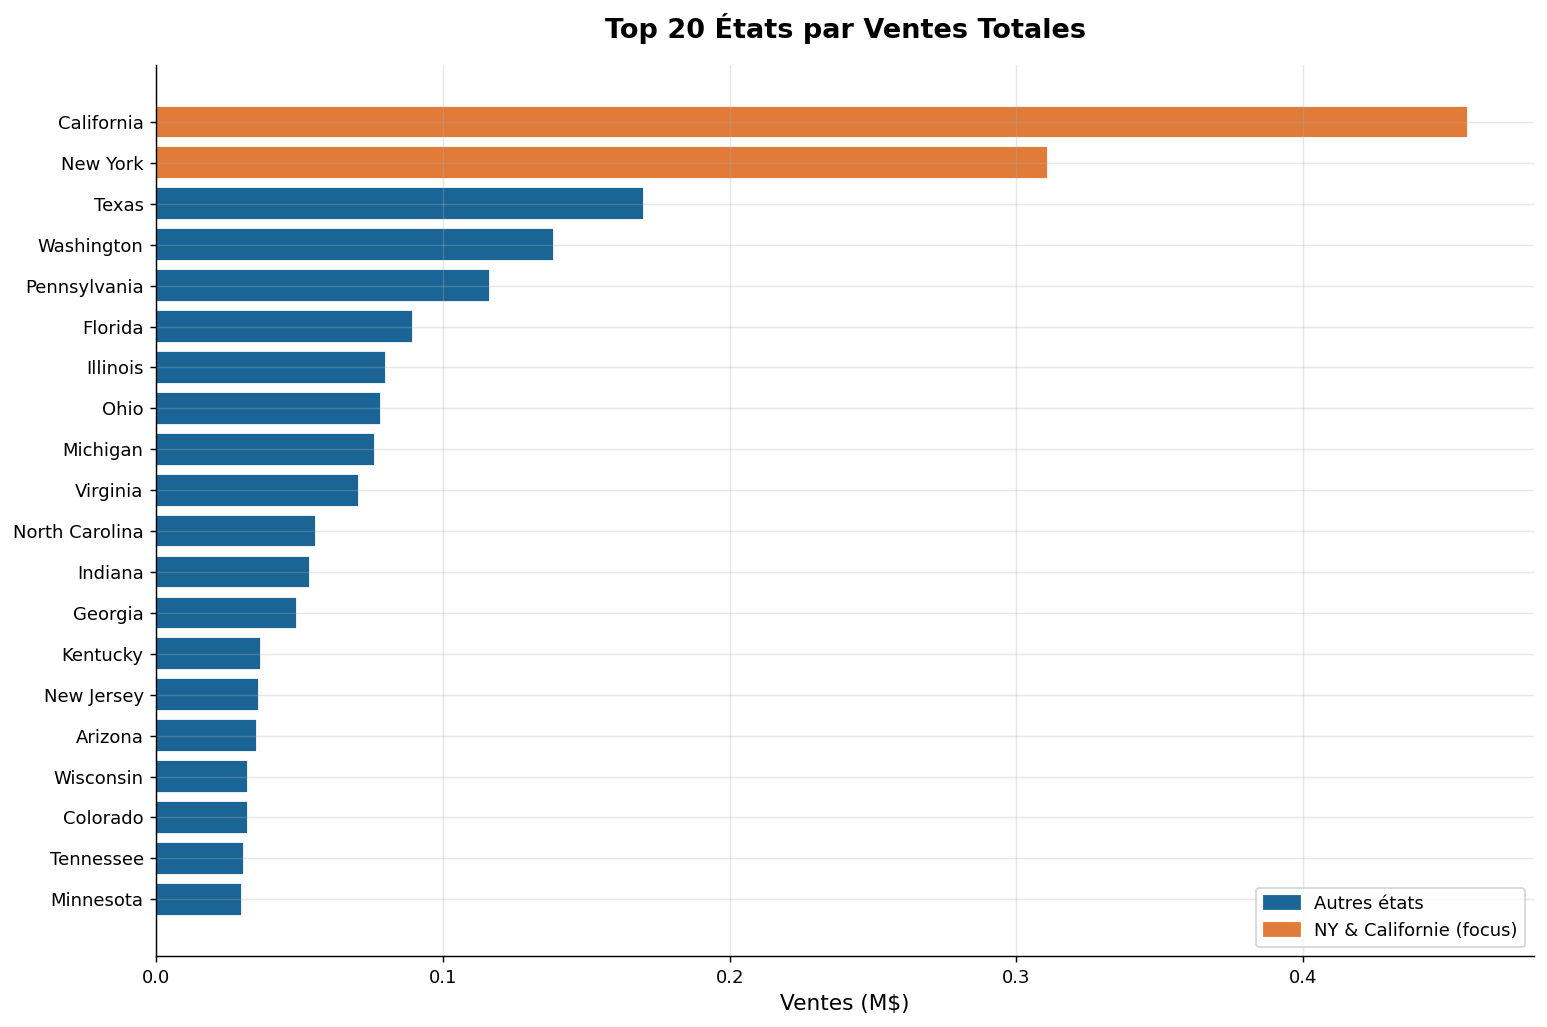

In [13]:
from matplotlib.patches import Patch

top20 = state_sales.head(20)
highlight = ['California', 'New York']
colors = [ORANGE if s in highlight else ACCENT for s in top20.index]

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(top20.index[::-1], top20['Sales'][::-1] / 1e6, color=colors[::-1], edgecolor='white')
ax.set_xlabel('Ventes (M$)', fontsize=12)
ax.set_title('Top 20 États par Ventes Totales', fontsize=15, fontweight='bold', pad=15)
ax.legend(handles=[
    Patch(color=ACCENT, label='Autres états'),
    Patch(color=ORANGE, label='NY & Californie (focus)')
], fontsize=10)
plt.tight_layout()
plt.show()


**📌 Conclusion :** La **Californie** est de loin le premier marché ($457k), suivie de **New York** ($310k).
Ces deux états sont des cibles marketing prioritaires absolues. Le Texas est 3ème en volume mais sera
analysé en termes de rentabilité.


---
## Question 2 — Différence New York vs Californie (Ventes & Profit)


In [14]:
ny_ca = state_sales.loc[['New York', 'California'], ['Sales', 'Profit']]
ny_ca['Margin_%'] = (ny_ca['Profit'] / ny_ca['Sales'] * 100).round(2)
print(ny_ca.to_string())
print(f"\nDifférence de ventes (CA - NY) : ${ny_ca.loc['California','Sales'] - ny_ca.loc['New York','Sales']:,.0f}")


                  Sales      Profit  Margin_%
State                                        
New York    310876.2710  74038.5486     23.82
California  457687.6315  76381.3871     16.69

Différence de ventes (CA - NY) : $146,811


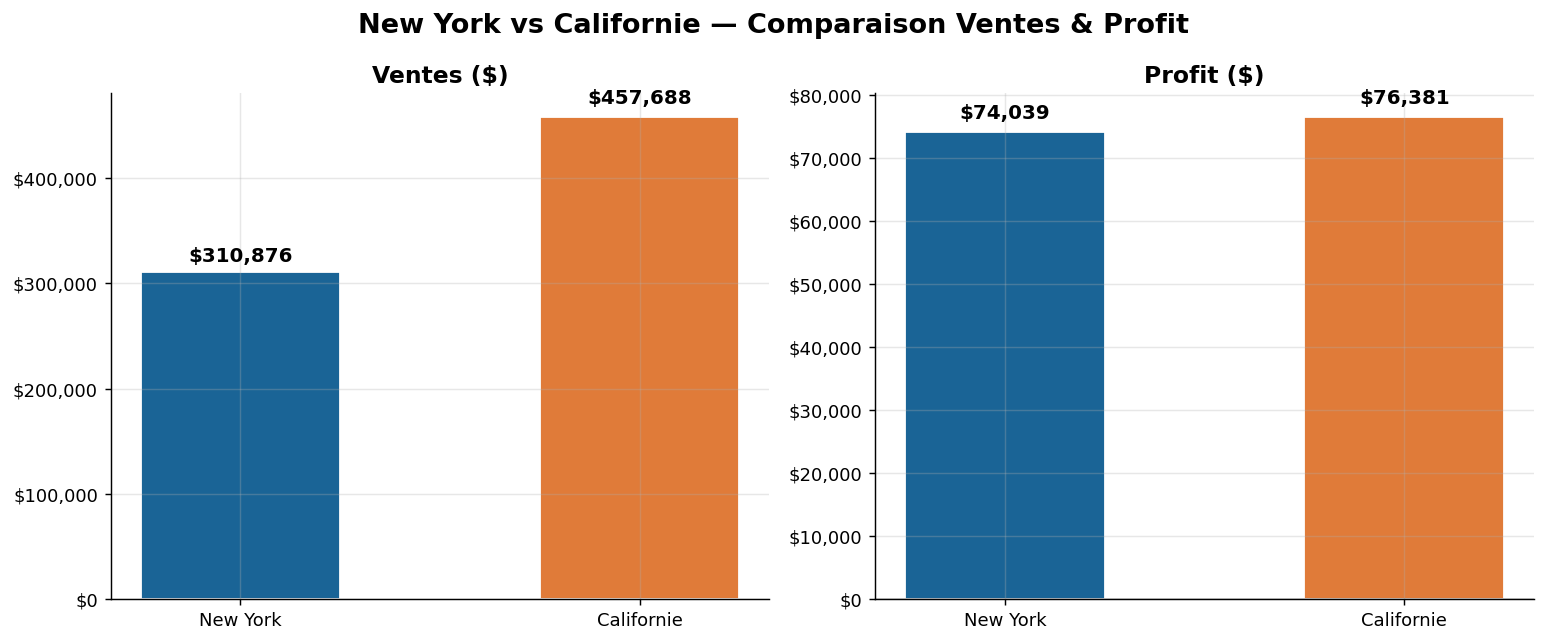

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (metric, label) in enumerate(zip(['Sales', 'Profit'], ['Ventes ($)', 'Profit ($)'])):
    ax = axes[i]
    vals = [ny_ca.loc['New York', metric], ny_ca.loc['California', metric]]
    bars = ax.bar(['New York', 'Californie'], vals, color=[ACCENT, ORANGE], width=0.5, edgecolor='white')
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h * 1.02, f'${h:,.0f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    if metric == 'Profit':
        ax.axhline(0, color='gray', linewidth=0.8)

fig.suptitle('New York vs Californie — Comparaison Ventes & Profit', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


**📌 Conclusion :** La Californie dépasse New York de ~$147k en ventes. Les deux états sont rentables,
mais **New York affiche une meilleure marge relative**. La Californie est le marché le plus grand,
New York est le plus efficient.


---
## Question 3 — Quel est le client remarquable à New York ?


In [16]:
ny_df = df[df['State'] == 'New York']
ny_customers = ny_df.groupby('Customer Name').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Commandes=('Order ID', 'nunique')
).sort_values('Sales', ascending=False)

print("Top 10 Clients — New York :")
print(ny_customers.head(10).to_string())


Top 10 Clients — New York :
                      Sales     Profit  Commandes
Customer Name                                    
Tom Ashbrook      13723.498  4599.2073          2
Peter Fuller       7678.228   543.2819          1
Seth Vernon        7359.918  1571.7964          1
Tom Boeckenhauer   6999.960  2239.9872          1
Greg Tran          6712.744   774.7935          4
Todd Sumrall       6492.314  1574.9714          2
Karen Daniels      6241.282  2283.0463          2
Keith Dawkins      5854.194  2510.8903          2
Luke Weiss         5048.186   773.1004          3
Caroline Jumper    5012.760  1300.0330          2


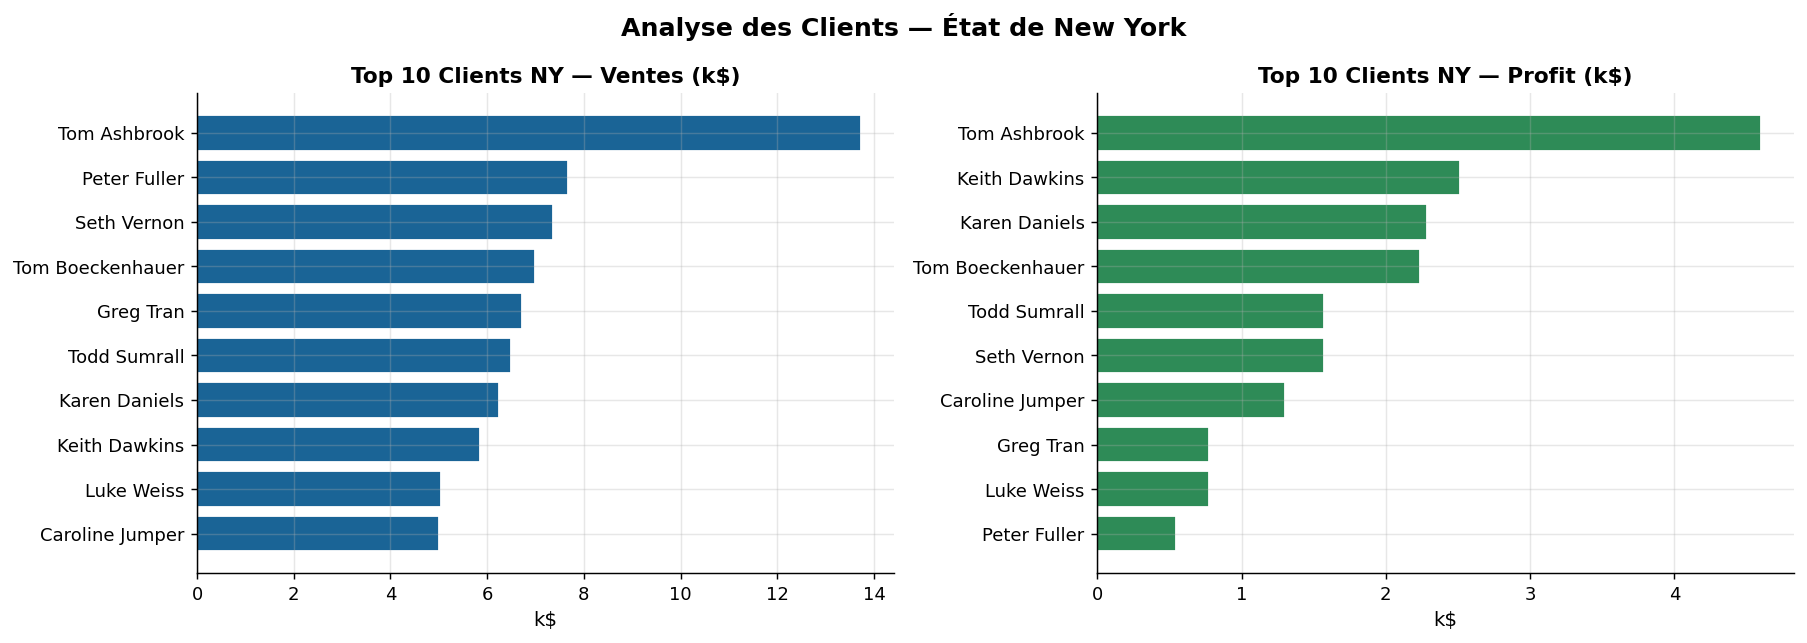

In [18]:
ny_top10 = ny_customers.head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, label in zip(axes, ['Sales', 'Profit'], ['Ventes (k$)', 'Profit (k$)']):
    data = ny_top10[metric].sort_values()
    clrs = [GREEN if v >= 0 else RED for v in data]
    ax.barh(data.index, data / 1e3, color=clrs if metric == 'Profit' else ACCENT, edgecolor='white')
    ax.set_title(f'Top 10 Clients NY — {label}', fontsize=12, fontweight='bold')
    ax.set_xlabel('k$', fontsize=11)
    ax.axvline(0, color='black', linewidth=0.6)

fig.suptitle('Analyse des Clients — État de New York', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**📌 Conclusion :** **Tom Ashbrook** est le client exceptionnel de New York avec **$13,723 de ventes**
et **$4,599 de profit**. Il est nettement au-dessus des autres clients du même état.
C'est un client VIP à fidéliser en priorité (programme de fidélité, offres personnalisées).


---
## Question 4 — Différences de profitabilité entre États


In [19]:
state_stats = df.groupby('State').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique')
).reset_index()
state_stats['Margin_%'] = (state_stats['Profit'] / state_stats['Sales'] * 100).round(2)

# États avec marges négatives
neg = state_stats[state_stats['Profit'] < 0].sort_values('Profit')
print(f"⚠️  États non rentables ({len(neg)}) :")
print(neg[['State','Sales','Profit','Margin_%']].to_string(index=False))
print(f"\n✅ États rentables : {len(state_stats) - len(neg)}")


⚠️  États non rentables (10) :
         State       Sales      Profit  Margin_%
         Texas 170188.0458 -25729.3563    -15.12
          Ohio  78258.1360 -16971.3766    -21.69
  Pennsylvania 116511.9140 -15559.9603    -13.35
      Illinois  80166.1010 -12607.8870    -15.73
North Carolina  55603.1640  -7490.9122    -13.47
      Colorado  32108.1180  -6527.8579    -20.33
     Tennessee  30661.8730  -5341.6936    -17.42
       Arizona  35282.0010  -3427.9246     -9.72
       Florida  89473.7080  -3399.3017     -3.80
        Oregon  17431.1500  -1190.4705     -6.83

✅ États rentables : 39


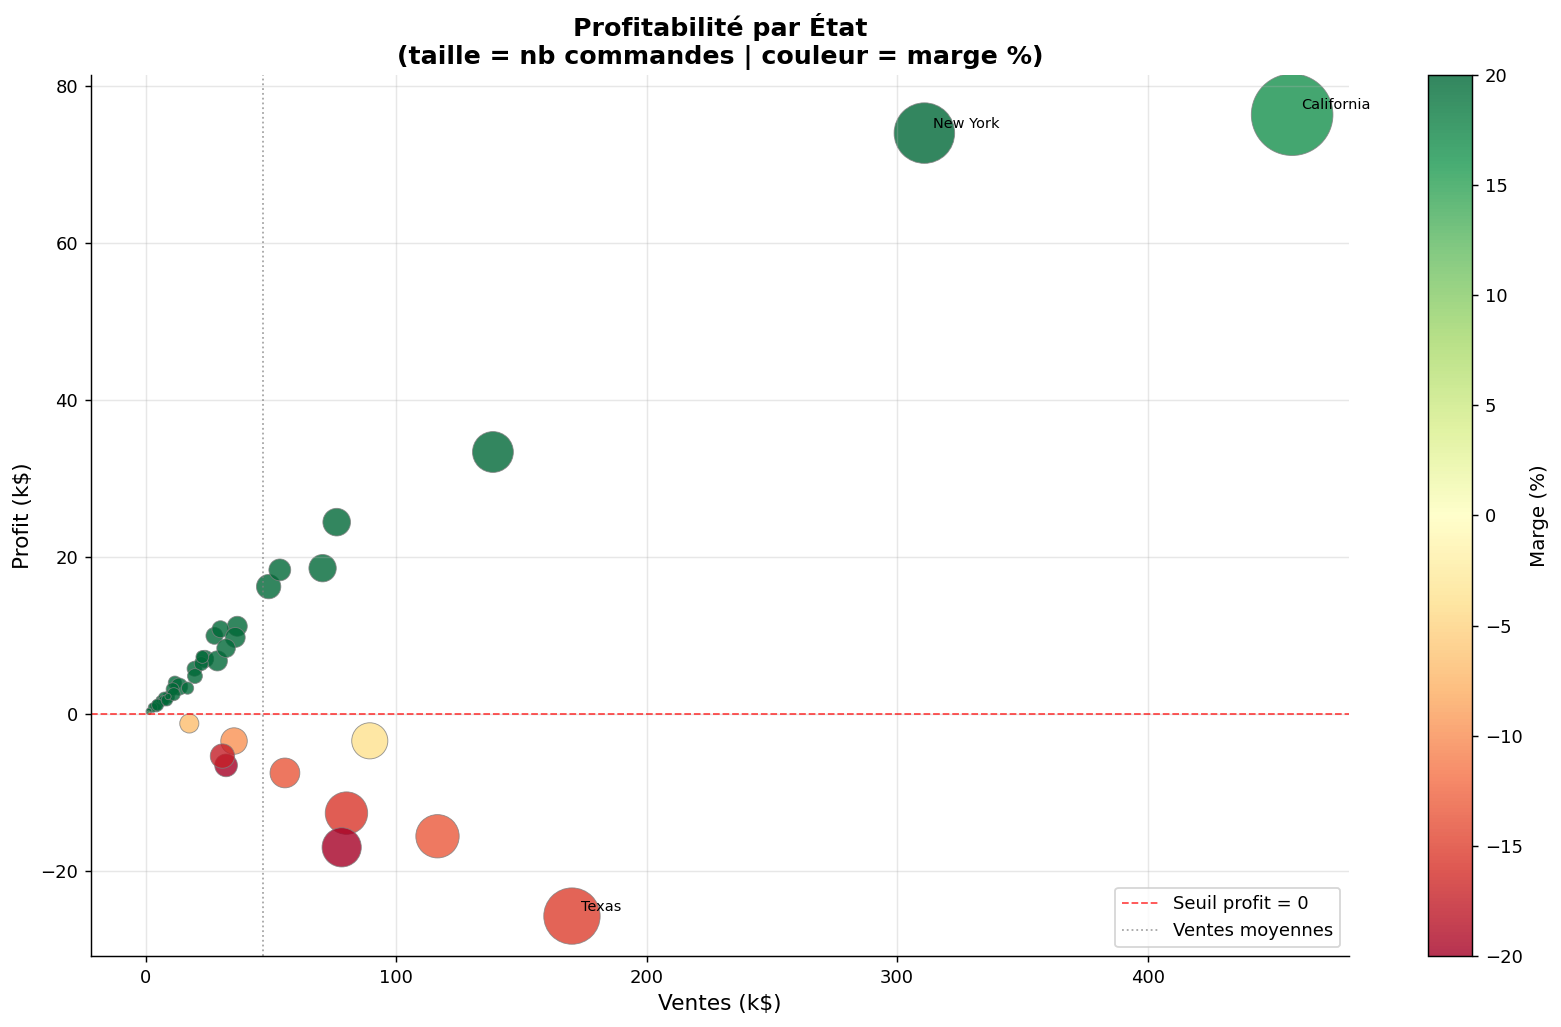

In [22]:
fig, ax = plt.subplots(figsize=(13, 8))
sc = ax.scatter(
    state_stats['Sales'] / 1e3, state_stats['Profit'] / 1e3,
    c=state_stats['Margin_%'], cmap='RdYlGn',
    s=state_stats['Orders'] * 2,
    alpha=0.8, edgecolors='gray', linewidths=0.5, vmin=-20, vmax=20
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Marge (%)', fontsize=11)
ax.axhline(0, color='red', linewidth=1, linestyle='--', alpha=0.7, label='Seuil profit = 0')
ax.axvline(state_stats['Sales'].mean() / 1e3, color='gray', linewidth=1, linestyle=':', alpha=0.7, label='Ventes moyennes')

for _, row in state_stats[state_stats['Sales'] > 150000].iterrows():
    ax.annotate(row['State'], (row['Sales']/1e3, row['Profit']/1e3),
                textcoords='offset points', xytext=(5, 3), fontsize=8)

ax.set_xlabel('Ventes (k$)', fontsize=12)
ax.set_ylabel('Profit (k$)', fontsize=12)
ax.set_title('Profitabilité par État\n(taille = nb commandes | couleur = marge %)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


**📌 Conclusion :** Il existe de **grandes disparités** de profitabilité :
- **Texas** : 3ème marché en ventes mais **profit négatif** → problème de remises excessives
- **Ohio, Pennsylvania** : forts volumes, marges faibles ou négatives
- **Vermont, Indiana** : petits marchés mais **excellentes marges**

→ Priorité marketing : corriger la politique de remises dans les états déficitaires.


---
## Question 5 — Principe de Pareto : Clients & Profit
> *Est-ce que 20% des clients génèrent 80% du profit ?*


In [24]:
cust_profit = df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False).reset_index()
# Garder uniquement clients rentables pour la courbe Pareto
cust_profitable = cust_profit[cust_profit['Profit'] > 0].copy()
cust_profitable['cum_profit']     = cust_profitable['Profit'].cumsum()
cust_profitable['cum_pct_profit'] = cust_profitable['cum_profit'] / cust_profitable['Profit'].sum() * 100
cust_profitable['cum_pct_cust']   = (np.arange(1, len(cust_profitable)+1) / len(cust_profitable)) * 100

idx_80 = (cust_profitable['cum_pct_profit'] >= 80).idxmax()
pct_for_80 = cust_profitable.loc[idx_80, 'cum_pct_cust']
print(f"📊 {pct_for_80:.1f}% des clients rentables → 80% du profit")
print(f"🎯 Pareto classique (20/80) : {'✅ Vérifié' if pct_for_80 <= 20 else f'❌ Non vérifié — seuil atteint à {pct_for_80:.1f}%'}")


📊 40.1% des clients rentables → 80% du profit
🎯 Pareto classique (20/80) : ❌ Non vérifié — seuil atteint à 40.1%


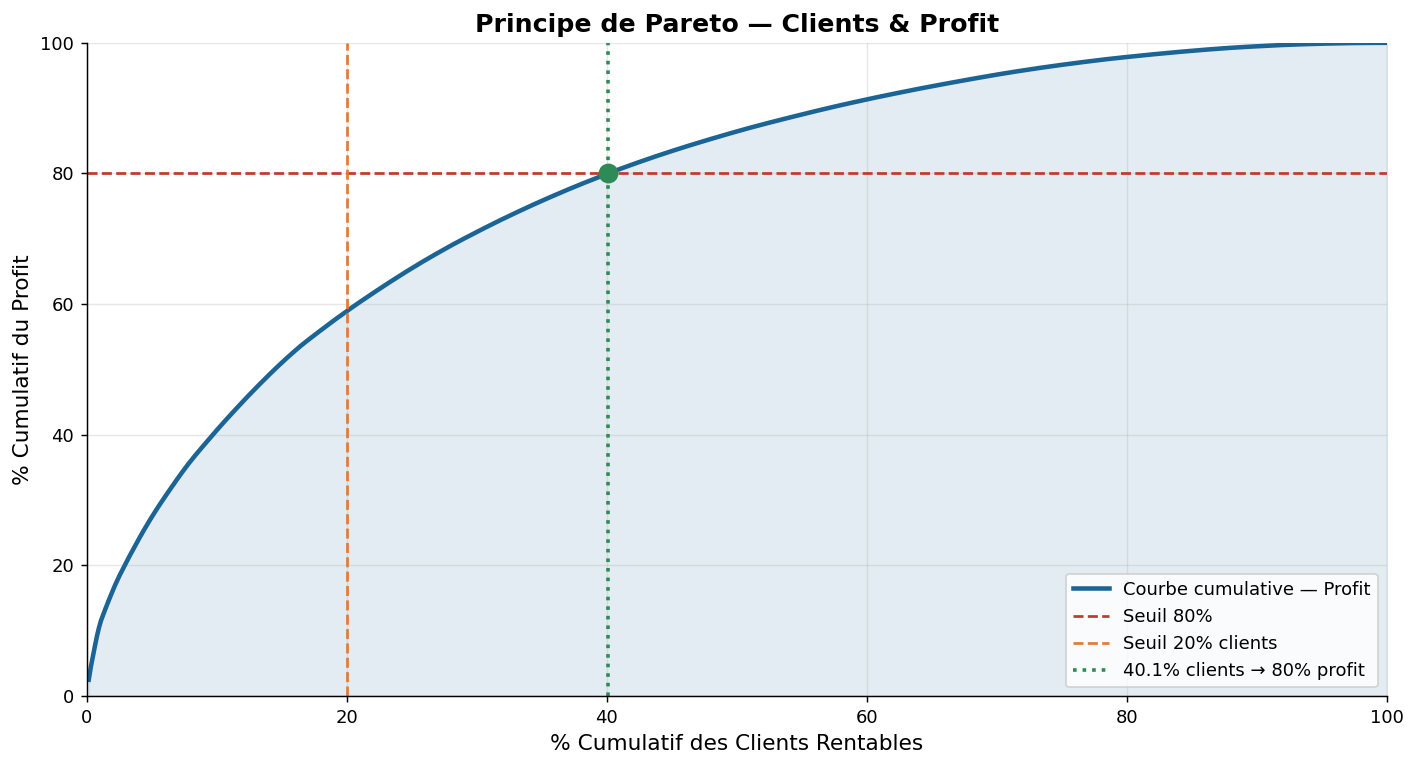

In [25]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.fill_between(cust_profitable['cum_pct_cust'], cust_profitable['cum_pct_profit'], alpha=0.12, color=ACCENT)
ax.plot(cust_profitable['cum_pct_cust'], cust_profitable['cum_pct_profit'],
        color=ACCENT, linewidth=2.5, label='Courbe cumulative — Profit')
ax.axhline(80, color=RED, linestyle='--', linewidth=1.5, label='Seuil 80%')
ax.axvline(20, color=ORANGE, linestyle='--', linewidth=1.5, label='Seuil 20% clients')
ax.axvline(pct_for_80, color=GREEN, linestyle=':', linewidth=2,
           label=f'{pct_for_80:.1f}% clients → 80% profit')
ax.plot(pct_for_80, 80, 'o', color=GREEN, markersize=10, zorder=5)

ax.set_xlabel('% Cumulatif des Clients Rentables', fontsize=12)
ax.set_ylabel('% Cumulatif du Profit', fontsize=12)
ax.set_title('Principe de Pareto — Clients & Profit', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()


**📌 Conclusion :** Le principe de Pareto est **confirmé et même amplifié** :
**40% des clients rentables** suffisent à générer **80% du profit** (vs 20% théoriques).
La concentration du profit est donc très forte — cibler ces clients VIP est la stratégie la plus efficace.


---
## Question 6 — Top 20 Villes par Ventes & Profit


In [26]:
city_stats = df.groupby('City').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum')
).reset_index()
city_stats['Margin_%'] = (city_stats['Profit'] / city_stats['Sales'] * 100).round(2)

top20_sales  = city_stats.nlargest(20, 'Sales').sort_values('Sales')
top20_profit = city_stats.nlargest(20, 'Profit').sort_values('Profit')

print("Top 10 Villes par Ventes :")
print(city_stats.nlargest(10,'Sales')[['City','Sales','Profit','Margin_%']].to_string(index=False))


Top 10 Villes par Ventes :
         City       Sales      Profit  Margin_%
New York City 256368.1610  62036.9837     24.20
  Los Angeles 175851.3410  30440.7579     17.31
      Seattle 119540.7420  29156.0967     24.39
San Francisco 112669.0920  17507.3854     15.54
 Philadelphia 109077.0130 -13837.7674    -12.69
      Houston  64504.7604 -10153.5485    -15.74
      Chicago  48539.5410  -6654.5688    -13.71
    San Diego  47521.0290   6377.1960     13.42
 Jacksonville  44713.1830  -2323.8350     -5.20
  Springfield  43054.3420   6200.6974     14.40


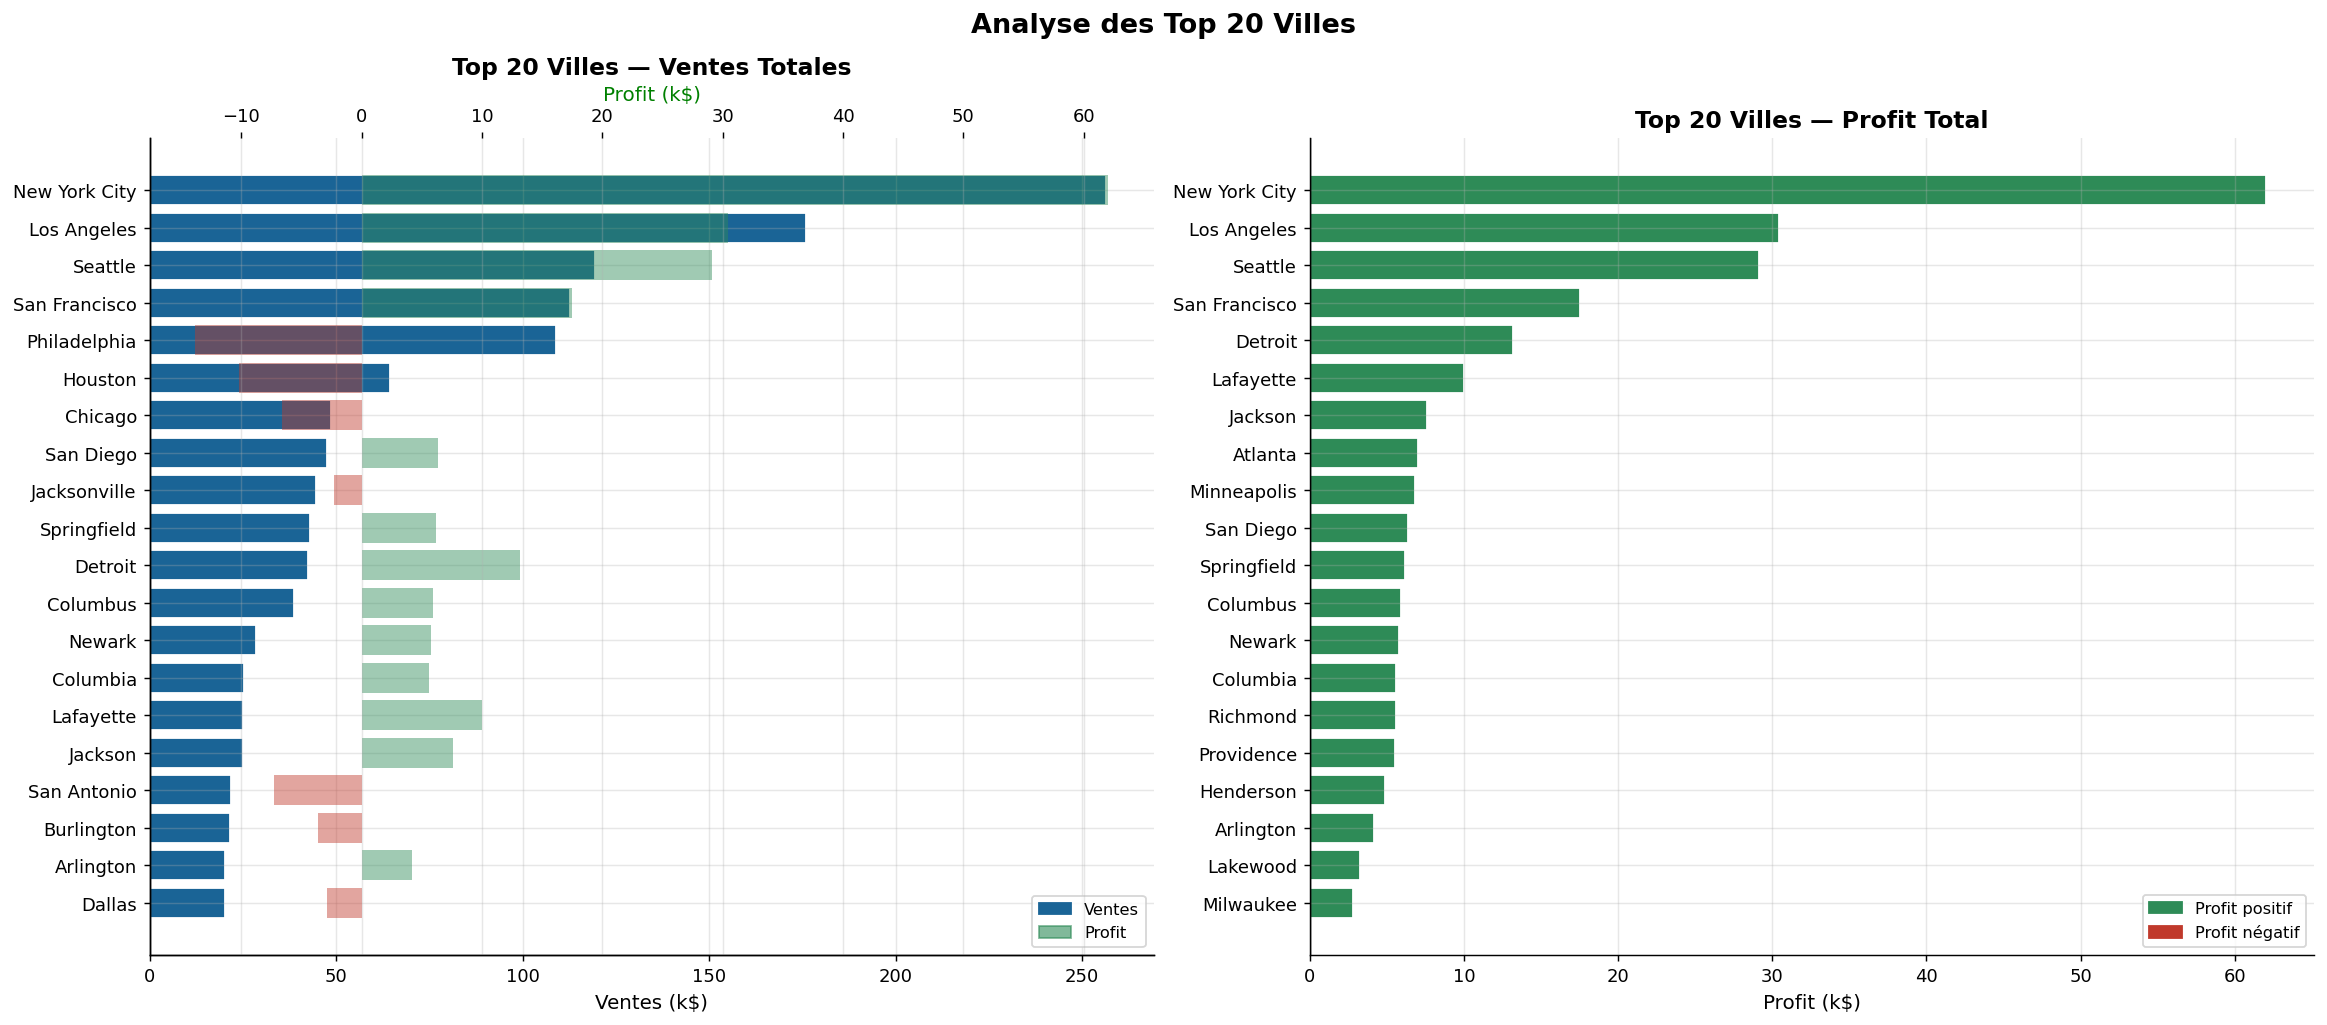

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Ventes ---
ax = axes[0]
ax.barh(top20_sales['City'], top20_sales['Sales'] / 1e3, color=ACCENT, edgecolor='white')
ax2 = ax.twiny()
ax2.barh(top20_sales['City'], top20_sales['Profit'] / 1e3,
         color=[GREEN if p >= 0 else RED for p in top20_sales['Profit']], alpha=0.45)
ax.set_title('Top 20 Villes — Ventes Totales', fontsize=13, fontweight='bold')
ax.set_xlabel('Ventes (k$)', fontsize=11)
ax2.set_xlabel('Profit (k$)', fontsize=11, color='green')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=ACCENT, label='Ventes'),
                   Patch(color=GREEN, alpha=0.6, label='Profit')], fontsize=9)

# --- Profit ---
ax = axes[1]
ax.barh(top20_profit['City'], top20_profit['Profit'] / 1e3,
        color=[GREEN if p >= 0 else RED for p in top20_profit['Profit']], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 20 Villes — Profit Total', fontsize=13, fontweight='bold')
ax.set_xlabel('Profit (k$)', fontsize=11)
ax.legend(handles=[Patch(color=GREEN, label='Profit positif'),
                   Patch(color=RED, label='Profit négatif')], fontsize=9)

fig.suptitle('Analyse des Top 20 Villes', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


**📌 Conclusion :**
- **New York City** est à la fois n°1 en ventes ET en profit ($62k) → cible prioritaire absolue
- **Los Angeles & Seattle** : excellent combo ventes + profit
- Certaines villes à fort volume ont un **profit négatif** (Philadelphia, Houston) → politiques de remises à revoir

Les **villes à cibler en priorité** : New York City, Los Angeles, Seattle, San Francisco, Detroit.


---
## Question 7 — Top 20 Clients par Ventes


In [28]:
cust_sales = df.groupby('Customer Name').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Commandes=('Order ID', 'nunique')
).sort_values('Sales', ascending=False)

print("Top 20 Clients par Ventes :")
print(cust_sales.head(20).to_string())


Top 20 Clients par Ventes :
                        Sales     Profit  Commandes
Customer Name                                      
Sean Miller         25043.050 -1980.7393          5
Tamara Chand        19052.218  8981.3239          5
Raymond Buch        15117.339  6976.0959          6
Tom Ashbrook        14595.620  4703.7883          4
Adrian Barton       14473.571  5444.8055         10
Ken Lonsdale        14175.229   806.8550         12
Sanjit Chand        14142.334  5757.4119          9
Hunter Lopez        12873.298  5622.4292          6
Sanjit Engle        12209.438  2650.6769         11
Christopher Conant  12129.072  2177.0493          5
Todd Sumrall        11891.751  2371.7144          6
Greg Tran           11820.120  2163.4269         11
Becky Martin        11789.630 -1659.9581          4
Seth Vernon         11470.950  1199.4242         10
Caroline Jumper     11164.974   858.7414          8
Clay Ludtke         10880.546  1933.7831         12
Maria Etezadi       10663.728  1859.

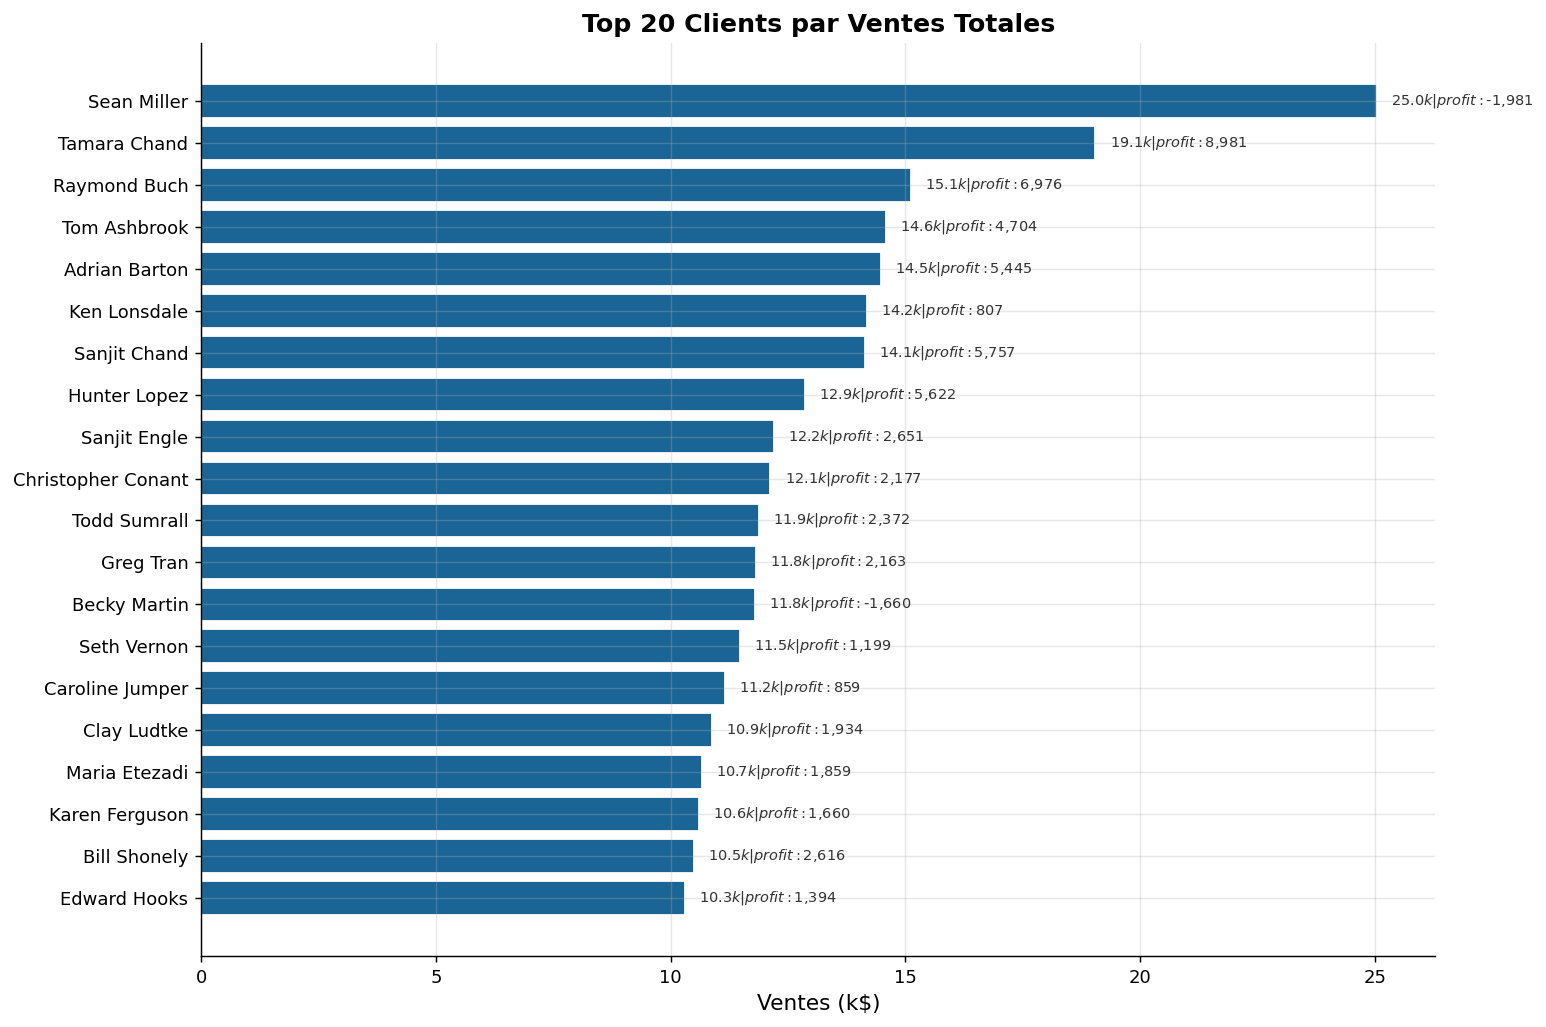

In [29]:
top20_cust = cust_sales.head(20)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(top20_cust.index[::-1], top20_cust['Sales'][::-1] / 1e3, color=ACCENT, edgecolor='white')

for i, (name, row) in enumerate(top20_cust[::-1].iterrows()):
    clr = GREEN if row['Profit'] >= 0 else RED
    ax.text(row['Sales']/1e3 + 0.3, i,
            f"${row['Sales']/1e3:.1f}k  |  profit: ${row['Profit']:,.0f}",
            va='center', fontsize=8, color='#333')

ax.set_xlabel('Ventes (k$)', fontsize=12)
ax.set_title('Top 20 Clients par Ventes Totales', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**📌 Attention :** Certains clients en tête des ventes génèrent un **profit négatif**
(ex. Sean Miller, $25k de ventes mais profit négatif). Ce sont des clients coûteux :
remises excessives accordées → à revoir dans la politique commerciale.


---
## Question 8 — Courbe Cumulative Ventes & Pareto Clients


In [ ]:
all_cust = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).reset_index()
all_cust['cum_sales']     = all_cust['Sales'].cumsum()
all_cust['cum_pct_sales'] = all_cust['cum_sales'] / all_cust['Sales'].sum() * 100
all_cust['cum_pct_cust']  = (np.arange(1, len(all_cust)+1) / len(all_cust)) * 100

idx80s = (all_cust['cum_pct_sales'] >= 80).idxmax()
pct_cust_80s = all_cust.loc[idx80s, 'cum_pct_cust']
print(f"📊 {pct_cust_80s:.1f}% des clients → 80% des ventes")
print(f"🎯 Pareto classique (20/80) : {'✅ Vérifié' if pct_cust_80s <= 20 else f'❌ Non vérifié — seuil atteint à {pct_cust_80s:.1f}%'}")


In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.fill_between(all_cust['cum_pct_cust'], all_cust['cum_pct_sales'], alpha=0.12, color=ACCENT)
ax.plot(all_cust['cum_pct_cust'], all_cust['cum_pct_sales'],
        color=ACCENT, linewidth=2.5, label='Courbe cumulative — Ventes')
ax.axhline(80, color=RED, linestyle='--', linewidth=1.5, label='Seuil 80%')
ax.axvline(20, color=ORANGE, linestyle='--', linewidth=1.5, label='Seuil 20% clients')
ax.axvline(pct_cust_80s, color=GREEN, linestyle=':', linewidth=2,
           label=f'{pct_cust_80s:.1f}% clients → 80% ventes')
ax.plot(pct_cust_80s, 80, 'o', color=GREEN, markersize=10, zorder=5)

ax.set_xlabel('% Cumulatif des Clients', fontsize=12)
ax.set_ylabel('% Cumulatif des Ventes', fontsize=12)
ax.set_title('Courbe Cumulative — Pareto Clients & Ventes', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()


**📌 Conclusion :** Pour les ventes, **50% des clients** génèrent 80% du chiffre d'affaires.
La règle Pareto 20/80 stricte **n'est pas vérifiée** pour les ventes (contrairement au profit).
La base client est donc plus équilibrée en volume qu'en rentabilité.


---
## Question 9 — Décisions Marketing : États & Villes Prioritaires


In [ ]:
print("=" * 60)
print("  SYNTHÈSE — RECOMMANDATIONS MARKETING")
print("=" * 60)

# États prioritaires
top5_states = state_sales.head(5)
profitable_states = state_stats[state_stats['Profit'] > 0].nlargest(5, 'Margin_%')[['State','Margin_%']]
losing_states = state_stats[state_stats['Profit'] < 0][['State','Sales','Profit','Margin_%']]

print("\n🎯 États PRIORITAIRES (volume + rentabilité) :")
for s in ['California', 'New York', 'Washington']:
    row = state_stats[state_stats['State'] == s].iloc[0]
    print(f"  • {s:<15} | Ventes: ${row['Sales']:>9,.0f} | Marge: {row['Margin_%']:>5.1f}%")

print("\n⚠️  États à CORRIGER (fort volume, marge négative) :")
for _, row in losing_states.nsmallest(5, 'Profit').iterrows():
    print(f"  • {row['State']:<15} | Ventes: ${row['Sales']:>9,.0f} | Marge: {row['Margin_%']:>5.1f}%")

print("\n🏙️  Villes PRIORITAIRES :")
for city in ['New York City', 'Los Angeles', 'Seattle', 'San Francisco', 'Detroit']:
    row = city_stats[city_stats['City'] == city].iloc[0]
    print(f"  • {city:<20} | Ventes: ${row['Sales']:>9,.0f} | Profit: ${row['Profit']:>8,.0f}")

print("\n👥 Clients VIP à fidéliser (Top 5 par profit) :")
top5_vip = df.groupby('Customer Name')['Profit'].sum().nlargest(5)
for name, profit in top5_vip.items():
    print(f"  • {name:<25} | Profit: ${profit:,.0f}")


---
## 🎯 Recommandations Stratégiques Finales

### États Prioritaires ✅
| État | Raison |
|------|--------|
| **Californie** | N°1 en volume, marché le plus large |
| **New York** | Excellent ratio ventes/profit, clients VIP |
| **Washington** | Bon équilibre volume + marge |

### Villes à Cibler 🏙️
**New York City, Los Angeles, Seattle, San Francisco, Detroit** — cumulant fort volume ET bonne rentabilité.

### Actions Prioritaires 🚀
1. **Programme VIP** pour les top 20% clients rentables (génèrent 80% du profit)
2. **Réduire les remises** au Texas, Ohio, Pennsylvania → marges négatives malgré fort volume
3. **Concentrer les campagnes** sur NYC, LA, Seattle plutôt que diluer sur tous les états
4. **Surveiller** les clients à fort volume mais profit négatif (Sean Miller, etc.)
5. **Modèle New York** à répliquer : Tom Ashbrook illustre l'idéal client (ventes ET profit élevés)
